In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd /content/drive/MyDrive/DL

/content/drive/MyDrive/DL


In [2]:
vocab_size = 508205
embedding_dim = 350

### Importing data

### Lazy Loading dataset

In [3]:
import torch
import torch.nn.functional as F
import torch.optim as op
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

In [4]:
class LazyCSVDataset(IterableDataset):
    def __init__(self, file_path, batch_size):
        self.file_path = file_path
        self.batch_size = batch_size
        with open(file_path) as f:
            self.length = sum(1 for _ in f) - 1  # skip header

    def __len__(self):
        return self.length

    def __iter__(self):
        with open(self.file_path) as f:
            next(f)  # skip header
            batch = []
            for line in f:
                values = list(map(int, line.strip().split(",")[1:]))
                batch.append(values)
                if len(batch) == self.batch_size:
                    yield torch.tensor(batch, dtype=torch.int)
                    batch = []
            if batch:
                yield torch.tensor(batch, dtype=torch.int)

In [5]:
# train = LazyCSVDataset('train.csv', 3500000)
val = LazyCSVDataset('val.csv', 1000000)

In [6]:
# train_loader = DataLoader(
#     train,
#     batch_size=None,
#     shuffle=False
# )
val_loader = DataLoader(
    val,
    batch_size=None,
    shuffle=False
)


In [7]:
import math

# num_batches_train = math.ceil(train.length / train.batch_size)
num_batches_val = math.ceil(val.length / val.batch_size)

# print(f"Total training samples: {train.length}, batch size: {train.batch_size}, num batches: {num_batches_train}")
print(f"Total validation samples: {val.length}, batch size: {val.batch_size}, num batches: {num_batches_val}")

Total validation samples: 41017853, batch size: 1000000, num batches: 42


In [8]:
val_loader

### Word2Vec

In [9]:
import torch
import torch.nn.functional as F
import torch.optim as op
from torch.utils.data import IterableDataset
from torch.utils.data import DataLoader

class Word2Vec(torch.nn.Module):
  def __init__(self, vocab_size, embedding_dim):
    super().__init__()
    self.input_embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)
    self.output_embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

  def func(self, x, y):
    e1 = self.input_embedding_layer(x)
    e2 = self.output_embedding_layer(y)

    return (e1 * e2).sum(dim=1)

  def forward(self, x, y):
    return self.func(x, y)

In [10]:
#model = Word2Vec(vocab_size, embedding_dim)

In [11]:
model = torch.load('Word2Vec_hindi.bin', weights_only=False)

In [12]:
model

Word2Vec(
  (input_embedding_layer): Embedding(508205, 350)
  (output_embedding_layer): Embedding(508205, 350)
)

In [13]:
model

Word2Vec(
  (input_embedding_layer): Embedding(508205, 350)
  (output_embedding_layer): Embedding(508205, 350)
)

In [14]:
model.requires_grad_(True)

Word2Vec(
  (input_embedding_layer): Embedding(508205, 350)
  (output_embedding_layer): Embedding(508205, 350)
)

In [15]:
model.input_embedding_layer.weight.requires_grad

True

In [16]:
model.output_embedding_layer.weight.requires_grad

True

#### Testing Model

In [ ]:
model.embedding_layer.weight.requires_grad = True
print(model.embedding_layer.weight.requires_grad)

True


In [ ]:
model = Word2Vec(10, 3)

In [ ]:
model

Word2Vec(
  (embedding_layer): Embedding(10, 3)
)

In [ ]:
x = torch.tensor([[1], [0], [2], [1]], dtype=torch.int)
y = torch.tensor([[0], [2], [1], [2]], dtype=torch.int)

In [ ]:
x.shape

torch.Size([4, 1])

In [ ]:
y

tensor([[0],
        [2],
        [1],
        [2]], dtype=torch.int32)

In [ ]:
model(x, y)

tensor([0.2682, 0.2518, 0.2400, 0.2400], grad_fn=<SoftmaxBackward0>)

In [ ]:
model(x, y).reshape((4))

tensor([0.2127, 0.3794, 0.8182, 0.8182], grad_fn=<ViewBackward0>)

#### Optimzer

In [17]:
lr = 0.01
optimizer = op.Adagrad(model.parameters(), lr=lr)
loss = torch.nn.BCEWithLogitsLoss()

In [18]:
from tqdm.auto import tqdm
def validate_model(model, train_loader, val_loader, device):
  val_loss = 0.0
  val_size = 0
  train_loss = 0.0
  train_size = 0
  model.eval()
  # input_dim_val = (len(x_val), 1)

  with torch.no_grad():
    for x in tqdm(train_loader, desc=f"Computing Train Loss", total=num_batches_train):
      context = x[:, 0].to(device)
      target = x[:, 1].to(device)
      labels = x[:, 2].to(device)
      scores = model(context, target)
      l = loss(scores, labels.float())
      train_loss += l.item() * context.shape[0]
      train_size += context.shape[0]

    for y in tqdm(val_loader, desc=f"Computing Validation Loss", total=num_batches_val):
      context = y[:, 0].to(device)
      target = y[:, 1].to(device)
      labels = y[:, 2].to(device)

      scores = model(context, target)
      l = loss(scores, labels.float())
      val_loss += l.item() * context.shape[0]
      val_size += context.shape[0]

  train_loss /= train_size
  val_loss /= val_size
  model.train()
  return train_loss, val_loss

In [ ]:
validate_model(model, train_loader, val_loader, 'cpu')

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

(0.576215375638538, 0.6742565823709875)

In [ ]:
from tqdm.auto import tqdm

epochs = 25

losses = []
val_losses = []
samples = 0

for epoch in range(epochs):
  i = 0
  for x in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", total=num_batches_train):
      context = x[:, 0].to('cpu')
      target = x[:, 1].to('cpu')
      labels = x[:, 2].to('cpu')

      batch_size = target.shape[0]

      # Forward
      scores = model(context, target)

      l = loss(scores, labels.float())

      # Backprop
      optimizer.zero_grad()
      l.backward()
      optimizer.step()
      i+=1

  train_loss, val_loss = validate_model(model, train_loader, val_loader, 'cpu')
  losses.append(train_loss)
  val_losses.append(val_loss)
  print(f"Epoch {epoch}, Loss: {losses[-1]}, Val_loss: {val_losses[-1]}")
  torch.save(model, "Word2Vec_hindi.bin")
  print(f"Model saved after {epoch+1} epochs")

Epoch 1/25:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 0, Loss: 3.0797672153927738, Val_loss: 3.1374556476502526
Model saved after 1 epochs


Epoch 2/25:   0%|          | 0/446 [00:00<?, ?it/s]

...

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 2, Loss: 1.5759158739680903, Val_loss: 1.6471820856916786
Model saved after 3 epochs


Epoch 4/25:   0%|          | 0/446 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from tqdm.auto import tqdm

epochs = 25

losses = []
val_losses = []
samples = 0

for epoch in range(3, epochs):
  i = 0
  for x in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", total=num_batches_train):
      context = x[:, 0].to('cpu')
      target = x[:, 1].to('cpu')
      labels = x[:, 2].to('cpu')

      batch_size = target.shape[0]

      # Forward
      scores = model(context, target)

      l = loss(scores, labels.float())

      # Backprop
      optimizer.zero_grad()
      l.backward()
      optimizer.step()
      i+=1

  train_loss, val_loss = validate_model(model, train_loader, val_loader, 'cpu')
  losses.append(train_loss)
  val_losses.append(val_loss)
  print(f"Epoch {epoch}, Loss: {losses[-1]}, Val_loss: {val_losses[-1]}")
  torch.save(model, "Word2Vec_hindi.bin")
  print(f"Model saved after {epoch+1} epochs")

Epoch 4/25:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 3, Loss: 0.8086815109914081, Val_loss: 0.8824820380255443
Model saved after 4 epochs


Epoch 5/25:   0%|          | 0/446 [00:00<?, ?it/s]

...

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 5, Loss: 0.6227606725347865, Val_loss: 0.7035734847471151
Model saved after 6 epochs


Epoch 7/25:   0%|          | 0/446 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [19]:
from tqdm.auto import tqdm

epochs = 25

losses = []
val_losses = []
samples = 0

for epoch in range(6, epochs):
  i = 0
  for x in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", total=num_batches_train):
      context = x[:, 0].to('cpu')
      target = x[:, 1].to('cpu')
      labels = x[:, 2].to('cpu')

      batch_size = target.shape[0]

      # Forward
      scores = model(context, target)

      l = loss(scores, labels.float())

      # Backprop
      optimizer.zero_grad()
      l.backward()
      optimizer.step()
      i+=1

  train_loss, val_loss = validate_model(model, train_loader, val_loader, 'cpu')
  losses.append(train_loss)
  val_losses.append(val_loss)
  print(f"Epoch {epoch}, Loss: {losses[-1]}, Val_loss: {val_losses[-1]}")
  torch.save(model, "Word2Vec_hindi.bin")
  print(f"Model saved after {epoch+1} epochs")

Epoch 7/25:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 6, Loss: 0.4588048148045274, Val_loss: 0.5463256648545466
Model saved after 7 epochs


Epoch 8/25:   0%|          | 0/446 [00:00<?, ?it/s]

...

Computing Train Loss:   0%|          | 0/446 [00:00<?, ?it/s]

Computing Validation Loss:   0%|          | 0/83 [00:00<?, ?it/s]

Epoch 8, Loss: 0.3761778603557112, Val_loss: 0.46948631140456254
Model saved after 9 epochs


Epoch 10/25:   0%|          | 0/446 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [20]:
epoch # Last Epoch

9

## Checking if model is able to differentiate between positive and negative examples

In [24]:
from tqdm.auto import tqdm
def validate_model_pos_neg(model, val_loader, device):
  pos_probs = 0.0
  neg_probs = 0.0
  pos_size = 0
  neg_size = 0
  model.eval()

  i = 0
  with torch.no_grad():
     for y in tqdm(val_loader, desc=f"Computing Validation probabs", total=num_batches_val):
      context = y[:, 0].to(device)
      target = y[:, 1].to(device)
      labels = y[:, 2].to(device)

      scores = model(context, target)
      probs = torch.sigmoid(scores)

      print(f"Iter {i+1}: \n\tpos_probs: {probs[labels == 1].mean()}\n\tneg_probs: {probs[labels == 0].mean()}\n\n")

      pos_probs += probs[labels == 1].sum().item()
      neg_probs += probs[labels == 0].sum().item()
      pos_size += probs[labels==1].size()[0]
      neg_size += probs[labels==0].size()[0]
      i+=1
  # print(pos_probs.mean(), neg_probs.mean())
  return pos_probs, pos_size, neg_probs, neg_size

In [26]:
pos_probs, pos_size, neg_probs, neg_size = validate_model_pos_neg(model, val_loader, 'cpu')

Computing Validation probabs:   0%|          | 0/42 [00:00<?, ?it/s]

Iter 1: 
	pos_probs: 0.9459969401359558
	neg_probs: 0.06820613145828247


Iter 2: 
	pos_probs: 0.9451609253883362
	neg_probs: 0.06831866502761841


Iter 3: 
	pos_probs: 0.9459574222564697
	neg_probs: 0.0677291601896286


Iter 4: 
	pos_probs: 0.9455665946006775
	neg_probs: 0.06816597282886505


Iter 5: 
	pos_probs: 0.9455710053443909
	neg_probs: 0.06781300157308578


Iter 6: 
	pos_probs: 0.9452902674674988
	neg_probs: 0.0680602490901947


Iter 7: 
	pos_probs: 0.945617139339447
	neg_probs: 0.06763148307800293


Iter 8: 
	pos_probs: 0.9452373385429382
	neg_probs: 0.06836595386266708


Iter 9: 
	pos_probs: 0.9452239274978638
	neg_probs: 0.06799552589654922


Iter 10: 
	pos_probs: 0.9456706643104553
	neg_probs: 0.06844377517700195


Iter 11: 
	pos_probs: 0.9458521604537964
	neg_probs: 0.06813130527734756


Iter 12: 
	pos_probs: 0.9454911351203918
	neg_probs: 0.06743372976779938


Iter 13: 
	pos_probs: 0.9452289342880249
	neg_probs: 0.06803073734045029


Iter 14: 
	pos_probs: 0.9456630945205

In [27]:
pos_probs/pos_size, neg_probs/neg_size

(0.9454712572910733, 0.06804573258503778)

In [ ]:
validate_model(model, val_loader, 'cuda')

Validation Loss: 0.43907198309898376


0.43907198309898376

In [ ]:
model.state_dict()

OrderedDict([('embedding_layer.weight',
              tensor([[-1.5617,  0.2000, -0.1036,  ..., -1.7763,  0.3546,  0.2116],
                      [-0.9671, -0.0299,  0.6944,  ..., -1.6503, -0.2011, -0.4231],
                      [ 0.0215, -2.3194,  0.0483,  ..., -0.3702,  0.6811,  0.2201],
                      ...,
                      [-0.3530,  0.2638,  0.2108,  ..., -0.6449,  0.5273,  0.3695],
                      [-0.7627,  0.8642,  0.7044,  ...,  1.6367,  0.1447,  0.8655],
                      [-1.7380, -1.7464, -0.7947,  ..., -1.4464, -1.2469,  0.1204]],
                     device='cuda:0'))])

#### Saving the model

In [28]:
torch.save(model, 'Word2Vec_model')

In [29]:
model = torch.load('Word2Vec_model', weights_only=False)

In [30]:
torch.save(model.input_embedding_layer.weight.data, "Word2Vec_hindi.bin")

In [31]:
model = torch.load('Word2Vec_hindi.bin')

In [32]:
model

tensor([[ 0.4351,  0.0768,  0.1519,  ...,  0.2191,  0.3150, -0.4386],
        [-0.0895, -0.2481, -0.3773,  ...,  0.1137,  0.3383,  0.1104],
        [-0.0400,  0.2068,  0.3334,  ...,  0.3171,  0.0302, -0.1119],
        ...,
        [-0.7186,  0.7624, -0.4571,  ..., -1.4069, -0.2833, -1.3150],
        [-1.4643,  0.3224, -0.5777,  ...,  0.2562, -1.3691, -0.3357],
        [-0.0587, -0.0903,  0.0913,  ...,  0.1201,  0.0541, -0.1180]])

In [34]:
embeddings = model

In [35]:
embeddings.size()

torch.Size([508205, 350])

In [36]:
import torch.nn.functional as F

In [37]:
import pandas as pd
word_int = pd.read_csv('vocabulary.csv').drop(['Unnamed: 0', 'count'], axis='columns')

In [38]:
word_int

,index,Word
0,0,के
1,1,है
2,2,में
3,3,की
4,4,और
...,...,...
508200,508200,अर्थानुरणन
508201,508201,ॠथियों
508202,508202,ॠणों
508203,508203,अर्थानुसार


In [39]:
word_int[word_int['Word'] == 'आदि']["index"].values[0]

np.int64(142)

In [40]:
def find_x_closest(word, n=5):
  embeddings = model
  word_index = int(word_int[word_int['Word'] == word]["index"].values[0])
  word_embedding = embeddings[word_index]

  # Calculate cosine similarity with all other embeddings
  # Add a dimension to word_embedding for broadcasting (1, embedding_dim)
  # and then transpose embeddings to (embedding_dim, vocab_size)
  # or simply iterate and calculate one by one. A more efficient way is to use matrix multiplication.
  # For now, let's use a simpler approach that's clear.
  similarities = F.cosine_similarity(word_embedding.unsqueeze(0), embeddings, dim=1)

  # Exclude the word itself from the results
  similarities[word_index] = -1.0 # Set to a very low value so it's not picked

  # Get the indices of the top n largest similarities
  # .topk returns a tuple of (values, indices)
  closest_indices = torch.topk(similarities, n).indices

  return word_int.iloc[closest_indices.tolist()]

In [41]:
find_x_closest('राजा')["Word"]

,Word
128,सकते
449,यात्रा
1759,शिखर
397,आर्थिक
825,निर्भर


In [42]:
import random as r
word = 'राजा'

for i in range(10):
  x = r.randint(0, 4)
  print(word, end=' ')
  word = find_x_closest(word)['Word'].values[x]

राजा शिखर ज़ालिम प्रशिक्षित ज्ञानोदय प्रशिक्षित 8 2# 1# दिया 

## Checking word embeddings

In [ ]:
import pandas as pd
word_int = pd.read_csv('vocabulary.csv').drop('Unnamed: 0', axis='columns')

In [ ]:
model = torch.load('Word2Vec_hindi.bin')

In [ ]:
model.detach

<function Tensor.detach>

In [44]:
embeddings = model.detach().cpu()

In [45]:
embeddings

tensor([[ 0.4351,  0.0768,  0.1519,  ...,  0.2191,  0.3150, -0.4386],
        [-0.0895, -0.2481, -0.3773,  ...,  0.1137,  0.3383,  0.1104],
        [-0.0400,  0.2068,  0.3334,  ...,  0.3171,  0.0302, -0.1119],
        ...,
        [-0.7186,  0.7624, -0.4571,  ..., -1.4069, -0.2833, -1.3150],
        [-1.4643,  0.3224, -0.5777,  ...,  0.2562, -1.3691, -0.3357],
        [-0.0587, -0.0903,  0.0913,  ...,  0.1201,  0.0541, -0.1180]])

In [46]:
testing_points = embeddings[:100]

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(testing_points)

In [48]:
reduced

array([[ 3.93289622e+00,  2.30428571e+00],
       [ 2.76387925e+00, -2.05713223e-01],
       [ 1.95387269e+00,  2.07511986e+00],
       [ 2.30667483e+00,  2.65228180e-01],
       [ 2.57823811e+00, -3.64581998e-02],
       [ 1.90457032e+00,  4.33842316e-01],
       [ 1.60266056e+00,  1.03592541e+00],
       [ 2.02611050e+00, -2.99725691e-03],
       [ 1.53349985e+00, -7.38329007e-02],
       [ 1.13882253e+00,  1.12944525e+00],
       [ 1.44620710e+00,  3.68480007e-01],
       [-5.50825541e-01,  1.50391872e+00],
       [ 1.31259911e+00, -6.74545397e-02],
       [ 1.02303133e+00,  5.18952916e-01],
       [ 1.26004491e+00,  3.39585760e-01],
       [ 1.08845633e+00, -3.92802743e-01],
       [-1.19228928e+00,  1.39842795e+00],
       [ 8.40940602e-01,  7.52383381e-01],
       [ 7.08482513e-01,  1.97596369e-01],
       [-6.42956940e-01,  1.39884850e+00],
       [ 6.60867988e-01,  2.15925728e-01],
       [ 8.31286736e-01,  3.69553901e-01],
       [ 7.59907776e-01,  2.55304017e-02],
       [ 6.

In [49]:
word_int["Word"].iloc[:100]

,Word
0,के
1,है
2,में
3,की
4,और
...,...
95,लोगों
96,क्षेत्र
97,उन्हें
98,9


In [50]:
!ls Noto*

NotoSansDevanagari-Regular.ttf


In [51]:
from matplotlib import font_manager

font_path = "NotoSansDevanagari-Regular.ttf"
font_prop = font_manager.FontProperties(fname=font_path)

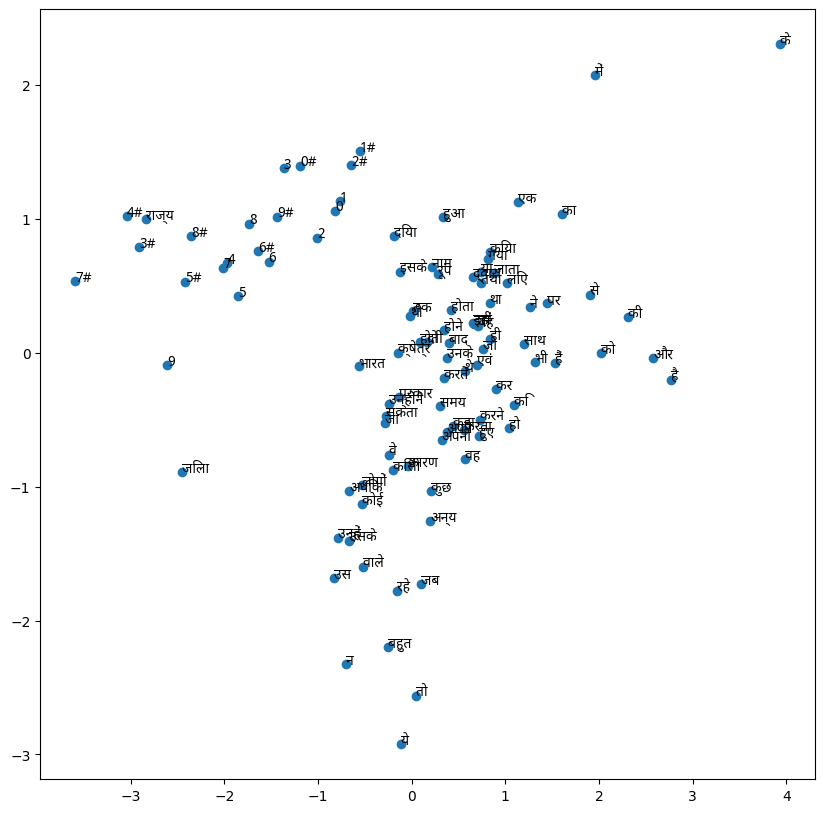

In [52]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.figure(figsize=(10, 10))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(word_int["Word"].iloc[:100]):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontproperties=font_prop)

plt.show()

In [53]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced = tsne.fit_transform(testing_points)

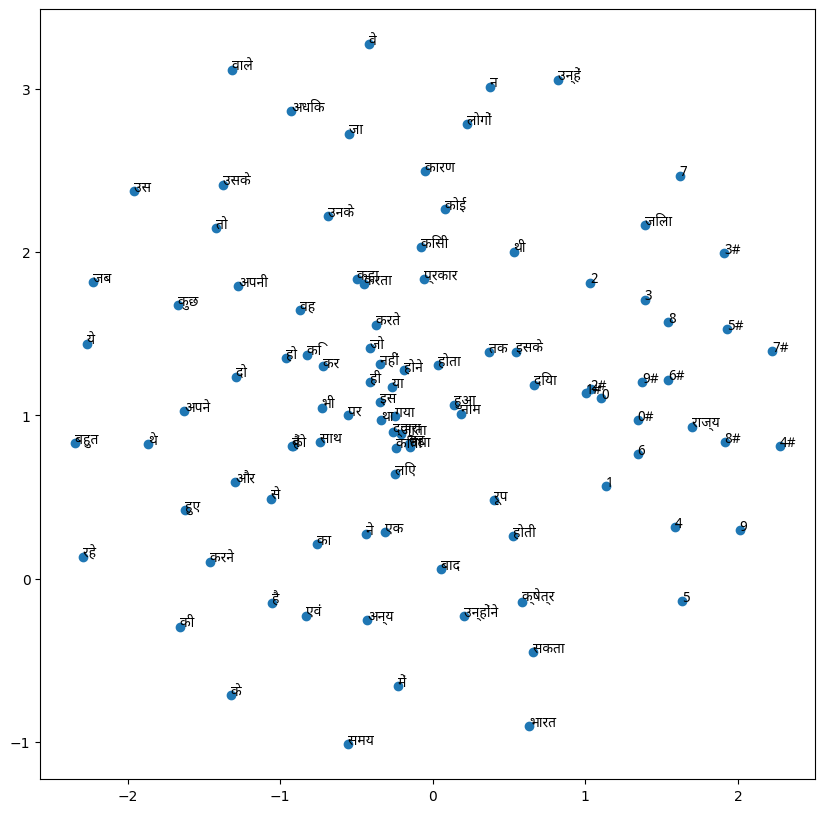

In [54]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

plt.figure(figsize=(10, 10))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, word in enumerate(word_int["Word"].iloc[:100]):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontproperties=font_prop)

plt.show()

### Huggingface upload

In [ ]:
!pip install huggingface_hub

In [ ]:
!huggingface-cli login


Hint: `hf` is already installed! Use it directly.

Hint: Examples:
  hf auth login
  hf download unsloth/gemma-4-31B-it-GGUF
  hf upload my-cool-model . .
  hf models ls --search "gemma"
  hf repos ls --format json
  hf jobs run python:3.12 python -c 'print("Hello!")'
  hf --help



In [ ]:
!hf auth login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: N
Token is valid (permission: write).
The token `Notebook_token` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Notebook

In [ ]:
!hf repo create word2vec-hindi

✓ Repo created
  repo_id: AbhishekBiswas12/word2vec-hindi
  url: https://huggingface.co/AbhishekBiswas12/word2vec-hindi


In [ ]:
/content/word2vec-hindi# git push
Username for 'https://huggingface.co': AbhishekBiswas12
Password for 'https://AbhishekBiswas12@huggingface.co':
remote: Password authentication in git is no longer supported. You must use a user access token or an SSH key instead. See https://huggingface.co/blog/password-git-deprecation
fatal: Authentication failed for 'https://huggingface.co/AbhishekBiswas12/word2vec-hindi/'

In [55]:
with open('Word2Vec_hindi/model/vocab.txt', 'w') as f:
  for word in word_int['Word']:
    f.write(word+'\n')